# 14. 아이러니 파헤치기: 잘 맞히는 품목일수록 미루기 어렵다

## Overview

13번에서 출하 시점 결정(H1)이 **+2.85%** 로 가장 유망하다는 결론이 나왔습니다.
"오른다" 하면 7거래일 미뤄서 팔고 "내린다" 하면 오늘 파는 전략입니다.

그런데 결론 끝에 걸리는 대목을 적어뒀습니다.

> **가장 잘 되는 품목이 가장 미루기 어려운 품목입니다.**
> 시금치 +7.44%, 상추 +4.66% 인데 둘 다 엽채류라 며칠이면 상합니다.

**이건 눈으로 본 인상일 뿐입니다.** 시금치·상추가 위에 있고 감자·양배추가 아래에
있다는 것만 봤지, 저장성을 숫자로 넣어본 적이 없습니다.

이 문서는 그걸 확인하고, 확인된다면 **실현 가능한 이득이 얼마인지**를 계산합니다.

## 목차

1. 저장 기간 붙이기
2. 가설: 상충이 실재하는가
3. 검증
4. 실현 가능한 이득
5. 창고비 한도: 보관비가 얼마까지면 남는가
6. 결론

## 이 문서에서 쓰는 말

표와 그래프 라벨을 [15번](15_confidence.ipynb)에서 정리한 표현으로 갈았습니다.
뜻은 그대로입니다.

| 예전 표현 | 지금 | 뜻 |
|---|---|---|
| H1 이득 | **더 받은 돈** | 그냥 오늘 팔았을 때보다 얼마나 더 벌었나 |
| 손익분기 보관비 | **창고비 한도** | 창고비가 이보다 비싸면 손해 |
| 미루는 비율 | **창고에 넣는 비율** | 며칠치를 안 팔고 미뤘나 |

핵심은 한 문장입니다.

> **창고에 넣어서 더 번 돈보다 창고비가 싸면 남는다.**

퍼센트가 둘이라 헷갈리기 쉬운데 **원 단위로는 같은 숫자**입니다. 더 번 만큼까지가
쓸 수 있는 창고비이기 때문입니다. 퍼센트가 갈리는 건 나누는 대상이 달라서입니다:
더 받은 돈은 **출하 전량**으로 나누고, 창고비 한도는 **창고에 넣은 물량**으로
나눕니다.

## 1. 저장 기간 붙이기

### 출처를 나눠 적습니다

농촌진흥청·농어민신문 등에서 확인된 값과, 그렇지 못해 유사 품목으로 추정한 값을
**구분해서** 씁니다. 추정치를 확인된 값처럼 쓰면 나중에 근거를 되짚을 수 없습니다.

| 품목 | 저장 가능 일수 | 근거 |
|---|---|---|
| 시금치 | 7 | 확인 (0℃, 습도 95~100%) |
| 상추 | 10 | 확인 (0~5℃, 습도 95%) |
| 배추 | 30 | 확인 (봄·여름 20~40일, 월동 40~60일 중 중간값) |
| 양배추 | 50 | 확인 (0~2℃, 필름포장) |
| 무 | 45 | 확인 (0~2℃, 습도 95~100%) |
| 감자 | 45 | 확인 (4~8℃, 30~60일) |
| 양파 | 165 | 확인 (0℃, 150~180일) |
| 얼갈이배추 | 10 | **추정** (어린 잎, 상추 수준) |
| 알배기배추 | 20 | **추정** (결구 배추보다 짧음) |
| 깻잎·미나리·열무·파 | 7 | **추정** (엽채류) |
| 풋고추·브로콜리 | 14 | **추정** (과채·화채류) |
| 고구마 | 60 | **추정** (서류) |
| 생강 | 90 | **추정** (근경) |
| 깐마늘(국산) | 30 | **추정** (가공품이라 통마늘보다 짧음) |
| 피마늘 | 180 | **추정** (통마늘) |

### 이 숫자가 뜻하는 것과 뜻하지 않는 것

**뜻하는 것**: 저온저장 시설에서 상품성을 유지할 수 있는 대략의 기간입니다.

**뜻하지 않는 것**: 저장하면 공짜라는 뜻이 아닙니다. 저장에는 시설비·전기료가 들고
무게가 줄며(감모) 등급이 떨어질 수 있습니다. 그건 5절에서 창고비 한도로 다룹니다.

**7거래일은 달력으로 약 9~10일입니다.** 주말이 끼기 때문입니다. 그래서 저장
가능 일수가 10일 미만인 품목은 이 전략을 실행할 수 없습니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

# 저장 가능 일수. 확인/추정을 함께 기록합니다.
STORAGE = {
    "시금치": (7, "확인"), "상추": (10, "확인"), "배추": (30, "확인"),
    "양배추": (50, "확인"), "무": (45, "확인"), "감자": (45, "확인"),
    "양파": (165, "확인"),
    "얼갈이배추": (10, "추정"), "알배기배추": (20, "추정"),
    "깻잎": (7, "추정"), "미나리": (7, "추정"), "열무": (7, "추정"),
    "파": (7, "추정"),
    "풋고추": (14, "추정"), "브로콜리": (14, "추정"),
    "고구마": (60, "추정"), "생강": (90, "추정"),
    "깐마늘(국산)": (30, "추정"), "피마늘": (180, "추정"),
}
storage = pd.DataFrame([{"item": k, "저장일수": v[0], "출처": v[1]}
                        for k, v in STORAGE.items()]).set_index("item")
print(f"{len(df):,}행 | 품목 {len(items)}개 | 저장기간 정의 {len(storage)}품목")
print("저장기간 미정의:", set(items) - set(storage.index) or "없음")

24,078행 | 품목 19개 | 저장기간 정의 19품목
저장기간 미정의: 없음


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 잘 맞히는 품목일수록 저장이 어렵다 | 저장일수와 더 받은 돈이 **음의 상관** |
| **H2** | 그래서 실현 가능한 이득은 크게 줄어든다 | 저장 가능 품목만 추리면 +2.85% 가 내려감 |

**H1 이 틀릴 수도 있는 이유**: 셋 다 별개일 수 있습니다. 저장성과 가격 변동성이
서로 무관한데 우연히 상위권에 엽채류가 몰렸을 수도 있습니다. 품목이 19개뿐이라
우연으로도 그런 배열이 나올 수 있습니다.

**주의할 점**: 저장일수는 제가 붙인 값이고 일부는 추정입니다. 상관이 나와도
"추정이 결과를 만든 것"일 수 있으므로, **확인된 7품목만으로도 같은 관계가
보이는지** 따로 확인합니다.

In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)
    t = te[["item", "price_date", "y", "오름", "price_kg_avg", "미래가격"]].copy()
    t["오른다예측"] = clf.predict_proba(te[FEATS])[:, 1] > 0.5
    out.append(t)
r = pd.concat(out).reset_index(drop=True)


def 출하이득(s):
    """오른다면 미뤄서 팔고 내린다면 오늘 판다. '항상 오늘' 대비 %."""
    실현 = np.where(s.오른다예측, s.미래가격.values, s.price_kg_avg.values)
    return (실현.mean() / s.price_kg_avg.mean() - 1) * 100


prof = pd.DataFrame({
    "더받은돈": r.groupby("item").apply(출하이득, include_groups=False),
    "방향적중": r.groupby("item").apply(lambda s: (s.오른다예측 == s.오름).mean() * 100,
                                     include_groups=False),
}).join(storage)
prof["실행가능"] = prof.저장일수 >= 10        # 7거래일 ≈ 10 달력일
print(f"준비 완료 ({time.time()-t0:.0f}초)")
display(prof.sort_values("더받은돈", ascending=False).round(2))

준비 완료 (12초)


,더받은돈,방향적중,저장일수,출처,실행가능
item,,,,,
시금치,7.44,65.67,7,확인,False
상추,4.66,67.05,10,확인,True
풋고추,4.47,68.08,14,추정,True
얼갈이배추,3.81,67.74,10,추정,True
배추,3.74,63.45,30,확인,True
미나리,3.47,68.97,7,추정,False
깻잎,3.44,63.38,7,추정,False
브로콜리,3.08,65.86,14,추정,True
알배기배추,3.00,63.46,20,추정,True


## 3. 검증: 상충이 실재하는가

저장일수와 더 받은 돈의 Spearman 상관
  전체 19품목      : -0.684
  출처 확인된 7품목 : -0.793

음수면 '저장이 잘 되는 품목일수록 이득이 작다' = 상충이 실재합니다.


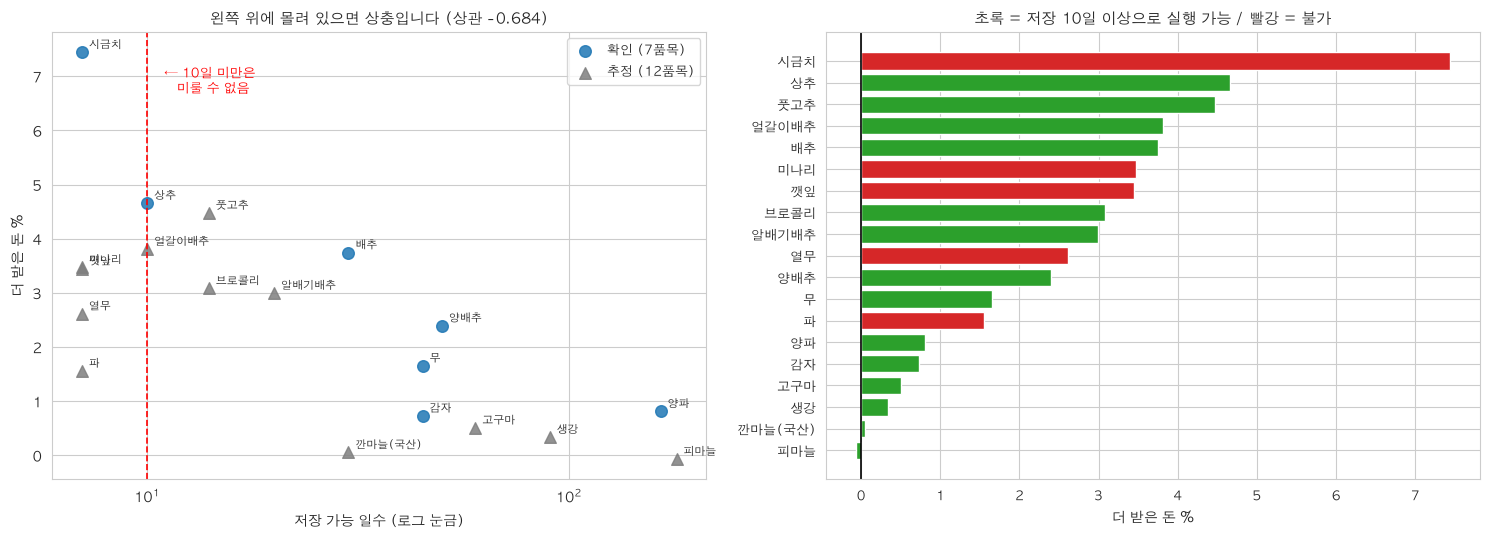

In [3]:
전체상관 = prof.저장일수.corr(prof.더받은돈, method="spearman")
확인만 = prof[prof.출처 == "확인"]
확인상관 = 확인만.저장일수.corr(확인만.더받은돈, method="spearman")

print("저장일수와 더 받은 돈의 Spearman 상관")
print(f"  전체 {len(prof)}품목      : {전체상관:+.3f}")
print(f"  출처 확인된 {len(확인만)}품목 : {확인상관:+.3f}")
print("\n음수면 '저장이 잘 되는 품목일수록 이득이 작다' = 상충이 실재합니다.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for 출처, mk, c in (("확인", "o", "tab:blue"), ("추정", "^", "tab:gray")):
    sub = prof[prof.출처 == 출처]
    ax.scatter(sub.저장일수, sub.더받은돈, s=70, marker=mk, color=c,
               alpha=0.85, label=f"{출처} ({len(sub)}품목)")
for it, row in prof.iterrows():
    ax.annotate(it, (row.저장일수, row.더받은돈), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.axvline(10, color="red", ls="--", lw=1.2)
ax.text(11, prof.더받은돈.max() * 0.9, "← 10일 미만은\n   미룰 수 없음",
        fontsize=9, color="red")
ax.set_xscale("log")
ax.set_xlabel("저장 가능 일수 (로그 눈금)")
ax.set_ylabel("더 받은 돈 %")
ax.set_title(f"왼쪽 위에 몰려 있으면 상충입니다 (상관 {전체상관:+.3f})", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
sub = prof.sort_values("더받은돈")
ax.barh(sub.index, sub.더받은돈,
        color=["tab:green" if v else "tab:red" for v in sub.실행가능])
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("더 받은 돈 %")
ax.set_title("초록 = 저장 10일 이상으로 실행 가능 / 빨강 = 불가", fontsize=11)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 4. 실제로 더 받을 수 있는 돈

저장 가능 일수가 **10일 이상**인 품목만 남기고 다시 계산합니다. 13번의 +2.85% 는
미룰 수 없는 품목까지 포함한 값이라 실제로는 달성할 수 없습니다.

In [4]:
가능품목 = prof[prof.실행가능].index.tolist()
불가품목 = prof[~prof.실행가능].index.tolist()

rows = []
for label, sel in (("전체 19품목 (13번 값)", items),
                   ("실행 가능 품목만", 가능품목),
                   ("실행 불가 품목만 (참고)", 불가품목)):
    s = r[r.item.isin(sel)]
    rows.append({
        "대상": label,
        "품목수": len(sel),
        "더 받은 돈 %": 출하이득(s),
        "방향 적중 %": (s.오른다예측 == s.오름).mean() * 100,
    })
display(pd.DataFrame(rows).round(2))

print("실행 가능:", ", ".join(가능품목))
print("실행 불가:", ", ".join(불가품목))

,대상,품목수,더 받은 돈 %,방향 적중 %
0,전체 19품목 (13번 값),19,2.85,62.84
1,실행 가능 품목만,14,2.07,62.56
2,실행 불가 품목만 (참고),5,4.05,63.57


실행 가능: 감자, 고구마, 깐마늘(국산), 무, 배추, 브로콜리, 상추, 생강, 알배기배추, 양배추, 양파, 얼갈이배추, 풋고추, 피마늘
실행 불가: 깻잎, 미나리, 시금치, 열무, 파


## 5. 창고비 한도: 보관비가 얼마까지면 남는가

저장에는 비용이 듭니다. 시설비·전기료가 들고 무게가 줄며(감모) 등급이 떨어질 수
있습니다. **그 비용 데이터가 저희에게 없습니다.**

없다고 손을 놓는 대신 **거꾸로 묻습니다**: "보관비가 몇 % 미만이면 이 전략이
남는가?"

계산이 단순합니다. 미루기로 결정한 날에만 비용이 드니, **미루는 비율 × 보관비**가
총비용입니다. 그게 이득보다 작아야 남습니다.

In [5]:
rows = []
for it in 가능품목:
    s = r[r.item == it]
    미루는비율 = s.오른다예측.mean()
    이득 = 출하이득(s)
    rows.append({
        "item": it,
        "저장일수": prof.loc[it, "저장일수"],
        "더 받은 돈 %": 이득,
        "창고에 넣는 비율 %": 미루는비율 * 100,
        "창고비 한도 %": 이득 / 미루는비율 if 미루는비율 > 0 else np.nan,
    })
be = pd.DataFrame(rows).set_index("item").sort_values("창고비 한도 %", ascending=False)
s_all = r[r.item.isin(가능품목)]
be.loc["— 실행가능 전체 —"] = [
    np.nan, 출하이득(s_all), s_all.오른다예측.mean() * 100,
    출하이득(s_all) / s_all.오른다예측.mean()]
display(be.round(2))
print("'창고비 한도'는 7거래일 보관 비용이 이 값보다 작으면 전략이 남는다는 뜻입니다.")
print("단위는 상품 가액 대비 % 입니다.")

,저장일수,더 받은 돈 %,창고에 넣는 비율 %,창고비 한도 %
item,,,,
상추,10.0,4.66,51.32,9.07
얼갈이배추,10.0,3.81,43.74,8.71
풋고추,14.0,4.47,54.99,8.14
배추,30.0,3.74,53.10,7.05
알배기배추,20.0,3.00,46.16,6.49
양배추,50.0,2.39,45.35,5.28
브로콜리,14.0,3.08,61.61,5.00
무,45.0,1.65,45.01,3.67
양파,165.0,0.81,40.97,1.98


'창고비 한도'는 7거래일 보관 비용이 이 값보다 작으면 전략이 남는다는 뜻입니다.
단위는 상품 가액 대비 % 입니다.


## 6. 결론

### 판정: 상충은 실재합니다

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 잘 맞히는 품목일수록 저장이 어렵다 | 상관 **-0.684** (확인 7품목만 **-0.793**) | **확인됨** |
| **H2** | 실현 가능한 이득은 크게 줄어든다 | +2.85% → **+2.07%** (27% 감소) | **확인됨** |

**추정치가 만든 결과가 아닙니다.** 출처가 확인된 7품목만으로 재도 상관이 -0.793 으로
오히려 더 강합니다. 제가 붙인 추정값이 관계를 만들어낸 게 아니라는 뜻입니다.

### 미룰 수 없는 품목이 상위를 차지합니다

| 품목 | 더 받은 돈 | 저장일수 | 실행 |
|---|---|---|---|
| **시금치** | **+7.44%** | 7일 | **불가** |
| 상추 | +4.66% | 10일 | 가능 |
| 풋고추 | +4.47% | 14일 | 가능 |
| 얼갈이배추 | +3.81% | 10일 | 가능 |
| 배추 | +3.74% | 30일 | 가능 |
| **미나리** | +3.47% | 7일 | **불가** |
| **깻잎** | +3.44% | 7일 | **불가** |
| … | | | |
| 양파 | +0.81% | 165일 | 가능 |
| 감자 | +0.73% | 45일 | 가능 |
| 피마늘 | -0.07% | 180일 | 가능 |

**1위 시금치(+7.44%)가 실행 불가**입니다. 실행 불가 5품목만 모으면 이득이 4.05% 로
실행 가능 14품목(2.07%)의 두 배입니다. 상충이 뚜렷합니다.

### 왜 이런 관계가 생기나

인과를 단정할 수는 없지만, 세 지표가 한 줄로 이어집니다.

**저장이 안 되는 품목은 그날 나온 물량을 그날 팔아야 합니다.** 재고로 수급을 고르게
할 수 없으니 작황·기상에 따라 가격이 크게 출렁입니다(10번에서 본 계절진폭: 시금치
4.98배 vs 양파 2.09배). **변동이 크면 방향만 맞혀도 크게 법니다.**

반대로 저장이 되는 품목은 재고가 완충 역할을 해서 가격이 완만합니다. 맞혀도 벌
폭이 작습니다. 피마늘이 극단입니다: 방향 적중률 67.1% 로 상위권인데 이득이
-0.07% 입니다.

**주의**: 이건 관찰된 관계이지 증명이 아닙니다. "저장성이 변동성을 낮춘다"를
말하려면 통제된 비교가 필요합니다.

### 그래서 실현 가능한 이득은 +2.07%

13번의 +2.85% 는 미룰 수 없는 품목까지 포함한 값이었습니다. 저장 10일 이상
품목만 남기면 **+2.07%** 입니다. 27% 가 깎였습니다.

### 창고비 한도: 보관비가 얼마까지면 남는가

보관비 데이터가 없어 거꾸로 계산했습니다. 미루기로 결정한 날에만 비용이 드니
**이득 ÷ 미루는 비율**이 창고비 한도입니다.

| 품목 | 창고비 한도 | 뜻 |
|---|---|---|
| 상추 | **9.07%** | 7거래일 보관비가 상품가의 9% 미만이면 남음 |
| 얼갈이배추 | 8.71% | |
| 풋고추 | 8.14% | |
| 배추 | 7.05% | |
| 양배추 | 5.28% | |
| **실행가능 전체** | **4.80%** | |
| 무 | 3.67% | |
| 양파 | 1.98% | 여유가 거의 없음 |
| 감자 | 1.32% | |
| 깐마늘 | 0.38% | 사실상 불가 |
| 피마늘 | **-0.74%** | 공짜여도 손해 |

**해석이 뒤집힙니다.** 저장이 가장 잘 되는 품목(양파 165일, 피마늘 180일)이
창고비 한도가 가장 낮습니다. **미룰 수 있어도 미룰 이유가 없습니다.**

쓸 만한 자리는 **중간 지대**입니다: 상추·얼갈이배추·풋고추·배추처럼 **10~30일
저장되면서 가격이 출렁이는** 품목들이 창고비 한도 7~9% 로 여유가 있습니다.

### 남은 한계

- **저장기간 12품목이 추정치**입니다. 확인 7품목으로도 결론이 유지되는 걸 봤지만,
  품목별 정확한 값은 현장 확인이 필요합니다.
- **저장 = 품질 유지가 아닙니다.** 10일 저장 가능이라도 신선도가 떨어져 등급이
  내려가면 가격이 깎입니다. 이 계산에는 그게 안 들어갔습니다.
- **감모(무게 감소)** 도 빠졌습니다. 저장 중 수분이 날아가면 파는 양 자체가 줍니다.
- 두 한계 다 **창고비 한도를 낮추는 방향**이라, 위 숫자는 낙관적인 상한입니다.

### 다음

1. **중간 지대 품목에 집중**: 상추·얼갈이배추·풋고추·배추 넷만 골라 재면
   **+4.41%** 로, 실행 가능 14품목 전체(+2.07%)의 두 배가 넘습니다. 이 넷으로
   좁히는 것이 가장 실질적인 다음 수입니다.
2. **보관비 실측치 확보**: 창고비 한도 4.80% 가 현실에서 넘는 수치인지 확인해야
   전략의 성패가 갈립니다. 저온저장고 운영비 자료를 찾아볼 수 있습니다.
3. **등급 하락을 반영**: KAMIS 에 등급별 가격이 있다면 저장 후 등급이 내려갈 때의
   손실을 넣을 수 있습니다.

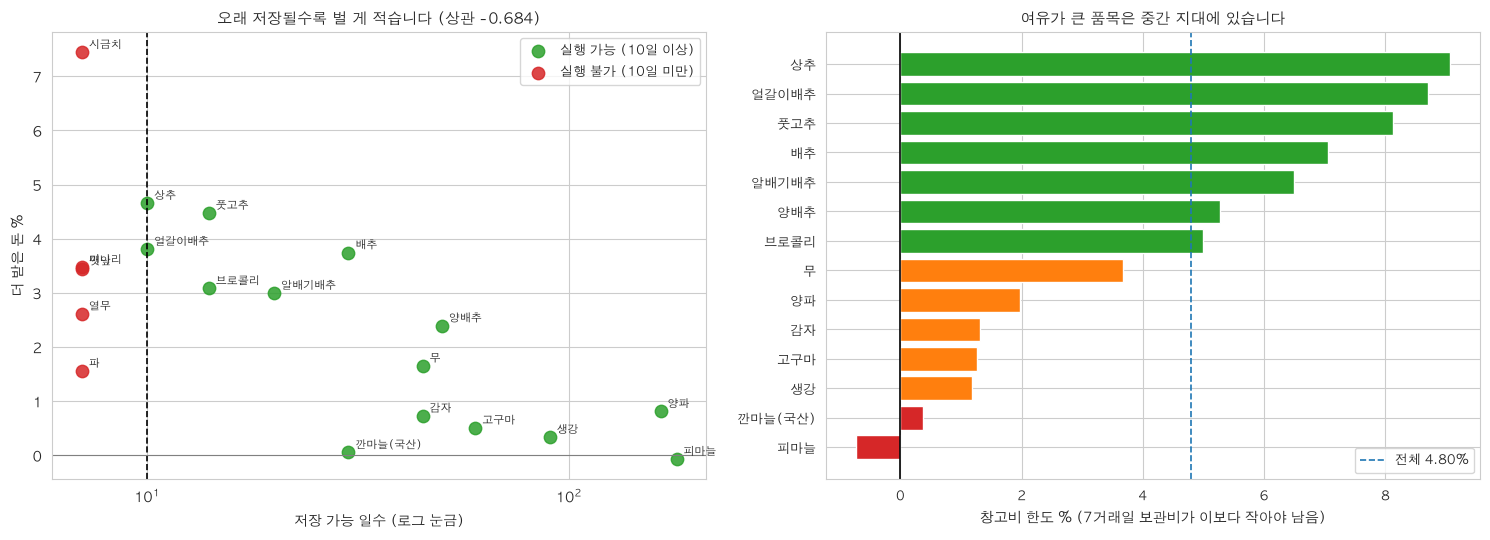

결론 요약 테이블


,구분,더 받은 돈 %
0,전체 19품목 (13번),2.85
1,실행 가능 14품목,2.07
2,중간지대 4품목,4.41


In [6]:
# 결론 그래프: 상충 관계와 창고비 한도
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (1) 상충: 저장일수 vs 이득, 실행 가능 여부로 색 구분
ax = axes[0]
for 가능, c, lb in ((True, "tab:green", "실행 가능 (10일 이상)"),
                   (False, "tab:red", "실행 불가 (10일 미만)")):
    sub = prof[prof.실행가능 == 가능]
    ax.scatter(sub.저장일수, sub.더받은돈, s=80, color=c, alpha=0.85, label=lb)
for it, row in prof.iterrows():
    ax.annotate(it, (row.저장일수, row.더받은돈), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.axvline(10, color="black", ls="--", lw=1.2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("저장 가능 일수 (로그 눈금)")
ax.set_ylabel("더 받은 돈 %")
ax.set_title(f"오래 저장될수록 벌 게 적습니다 (상관 {전체상관:+.3f})", fontsize=11)
ax.legend(fontsize=9)

# (2) 창고비 한도
ax = axes[1]
be2 = be.drop(index="— 실행가능 전체 —").sort_values("창고비 한도 %")
cols = ["tab:green" if v > 4 else "tab:orange" if v > 1 else "tab:red"
        for v in be2["창고비 한도 %"]]
ax.barh(be2.index, be2["창고비 한도 %"], color=cols)
ax.axvline(0, color="black", lw=1.2)
ax.axvline(be.loc["— 실행가능 전체 —", "창고비 한도 %"],
           color="tab:blue", ls="--", lw=1.2,
           label=f"전체 {be.loc['— 실행가능 전체 —','창고비 한도 %']:.2f}%")
ax.set_xlabel("창고비 한도 % (7거래일 보관비가 이보다 작아야 남음)")
ax.set_title("여유가 큰 품목은 중간 지대에 있습니다", fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print("결론 요약 테이블")
요약 = pd.DataFrame({
    "구분": ["전체 19품목 (13번)", "실행 가능 14품목", "중간지대 4품목"],
    "더 받은 돈 %": [출하이득(r),
                 출하이득(r[r.item.isin(가능품목)]),
                 출하이득(r[r.item.isin(["상추", "얼갈이배추", "풋고추", "배추"])])],
})
display(요약.round(2))